# Exploratory Data Analysis (EDA)
**ContextFlow AI** — Enterprise Knowledge Assistant

Notebook ini terbagi menjadi **2 sesi**:
1. **Sesi 1** — EDA pada dataset RAW (dari disk & database)
2. **Sesi 2** — EDA pada dataset yang sudah di-preprocess (formatted)

Analisis meliputi:
- Distribusi panjang teks (instruction & response)
- Distribusi kategori/sumber dataset
- Statistik deskriptif
- Visualisasi: Histogram, Boxplot, Pie Chart, Scatter Plot, Heatmap

In [1]:
import sys, os, warnings
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_from_disk, Dataset
from app.utils.config import config

warnings.filterwarnings('ignore')
plt.style.use('dark_background')
sns.set_palette('husl')
print('Imports OK')

d:\bootcamp\final_project_fine_tuning\contextflow_ai_fine_tuning\venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


---
# SESI 1 — EDA Dataset RAW
Membaca **semua dataset mentah** dari disk (`data/raw/`) dan database Supabase.

## 1.1 Load Raw Datasets dari Disk

In [2]:
raw_parts = []
RAW_DIR = config.RAW_DATA_DIR

for source in ['dolly', 'alpaca', 'openassistant', 'coqa']:
    path = os.path.join(RAW_DIR, source)
    if not os.path.exists(path):
        print(f'  {source}: NOT FOUND — skip')
        continue
    ds = load_from_disk(path).to_pandas()
    if 'source' not in ds.columns:
        ds['source'] = source
    raw_parts.append(ds)
    print(f'  {source}: {len(ds)} samples | cols={list(ds.columns)}')

# Load company raw dari disk
try:
    from app.preprocessing.company_loader import load_company_data
    cds = load_company_data()
    if cds is not None and len(cds) > 0:
        cdf = cds.to_pandas()
        cdf['source'] = 'company'
        raw_parts.append(cdf)
        print(f'  company (files): {len(cdf)} samples')
except Exception as e:
    print(f'  company files: {e}')

# Load company dari Supabase
try:
    from app.database.supabase_client import get_supabase
    db = get_supabase()
    if db:
        recs, off = [], 0
        while True:
            r = db.table('company_data').select('*').range(off, off+999).execute()
            if not r.data: break
            recs.extend(r.data)
            off += 1000
            if len(r.data) < 1000: break
        if recs:
            dbdf = pd.DataFrame(recs)
            dbdf['source'] = 'company_db'
            raw_parts.append(dbdf)
            print(f'  company (DB): {len(dbdf)} samples')
except Exception as e:
    print(f'  company DB: {e}')

if raw_parts:
    df_raw = pd.concat(raw_parts, ignore_index=True)
    print(f'\nTotal RAW: {len(df_raw)} samples')
else:
    df_raw = pd.DataFrame()
    print('No raw data found')

  dolly: 5000 samples | cols=['instruction', 'context', 'response', 'category', 'source']
  alpaca: 5000 samples | cols=['instruction', 'input', 'output', 'text', 'source']
  openassistant: 5000 samples | cols=['message_id', 'parent_id', 'user_id', 'created_date', 'text', 'role', 'lang', 'review_count', 'review_result', 'deleted', 'rank', 'synthetic', 'model_name', 'detoxify', 'message_tree_id', 'tree_state', 'emojis', 'labels', 'source']
  coqa: 5000 samples | cols=['source', 'story', 'questions', 'answers']
2026-05-20 08:49:01 | INFO | app.preprocessing.company_loader:215 -   Generated 1000 Q&A pairs from business CSV amsterdam-business-dataset-sample.csv
2026-05-20 08:49:01 | INFO | app.preprocessing.company_loader:215 -   Generated 1000 Q&A pairs from business CSV berlin-business-dataset-sample.csv
2026-05-20 08:49:01 | INFO | app.preprocessing.company_loader:215 -   Generated 1000 Q&A pairs from business CSV london-business-dataset-sample.csv
2026-05-20 08:49:01 | INFO | app.prepr

## 1.2 Informasi Dasar — Raw

In [3]:
if not df_raw.empty:
    print(f'Shape: {df_raw.shape}')
    print(f'Columns: {list(df_raw.columns)}')
    print(f'\nSource distribution:')
    print(df_raw['source'].value_counts())
    df_raw.head(5)

Shape: (36010, 34)
Columns: ['instruction', 'context', 'response', 'category', 'source', 'input', 'output', 'text', 'message_id', 'parent_id', 'user_id', 'created_date', 'role', 'lang', 'review_count', 'review_result', 'deleted', 'rank', 'synthetic', 'model_name', 'detoxify', 'message_tree_id', 'tree_state', 'emojis', 'labels', 'story', 'questions', 'answers', 'id', 'city', 'company_name', 'source_file', 'source_type', 'created_at']

Source distribution:
source
company          8005
company_db       8005
dolly            5000
alpaca           5000
openassistant    5000
cnn              1184
race             1181
gutenberg        1127
wikipedia        1120
mctest            388
Name: count, dtype: int64


## 1.3 Distribusi Panjang Teks — Raw

In [4]:
if not df_raw.empty:
    # Normalize column names
    col_map = {}
    for c in df_raw.columns:
        cl = c.lower()
        if cl in ('response','output','answer'): col_map.setdefault('_output', c)
        if cl in ('instruction','question'): col_map.setdefault('_instr', c)
        if cl in ('context','input'): col_map.setdefault('_input', c)

    oc = col_map.get('_output','output')
    ic = col_map.get('_instr','instruction')
    xc = col_map.get('_input','input')

    for c in [oc, ic, xc]:
        if c in df_raw.columns:
            df_raw[c] = df_raw[c].fillna('').astype(str)

    if ic in df_raw.columns:
        df_raw['instruction_length'] = df_raw[ic].str.len()
    if oc in df_raw.columns:
        df_raw['output_length'] = df_raw[oc].str.len()
    if xc in df_raw.columns:
        df_raw['input_length'] = df_raw[xc].str.len()

    len_cols = [c for c in ['instruction_length','output_length','input_length'] if c in df_raw.columns]
    print(df_raw[len_cols].describe())

       instruction_length  output_length  input_length
count        36010.000000   36010.000000  36010.000000
mean            45.564565     151.276173    155.075979
std             42.579724     275.439221    399.802942
min              0.000000       0.000000      0.000000
25%              0.000000       0.000000      0.000000
50%             53.000000     189.000000      0.000000
75%             66.000000     231.000000    239.000000
max           2545.000000   26018.000000  23505.000000


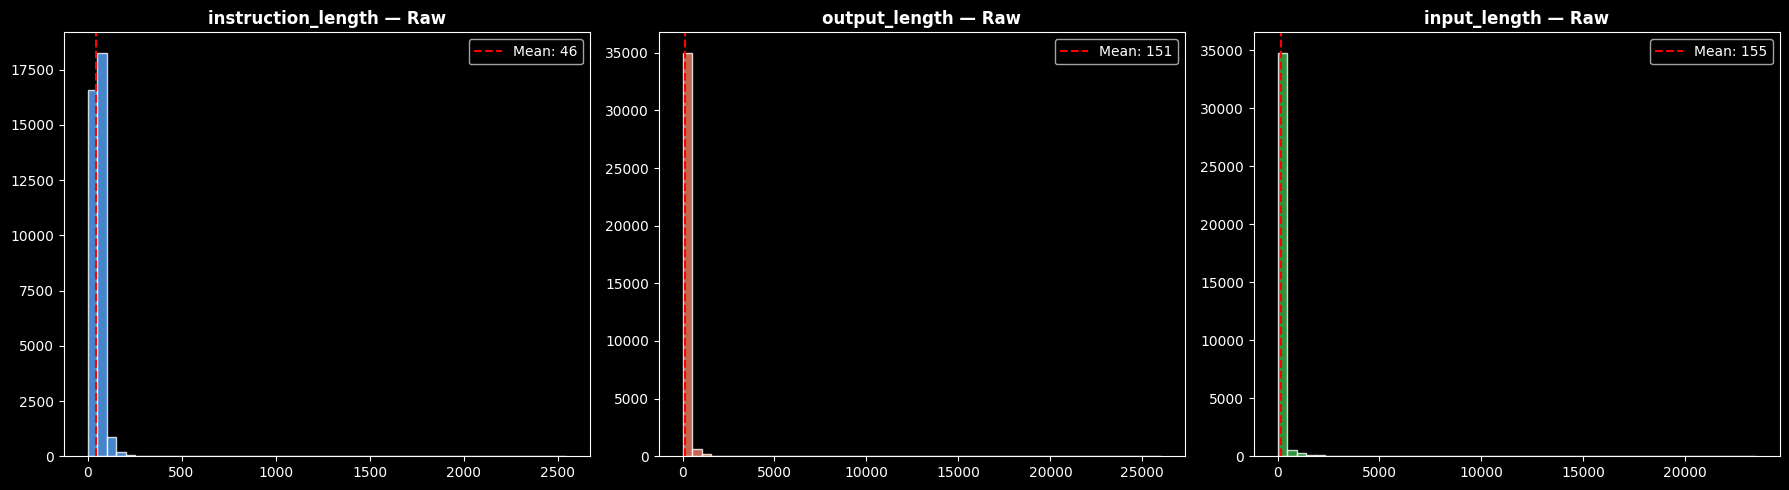

In [5]:
if not df_raw.empty and len_cols:
    n = len(len_cols)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1: axes = [axes]
    colors = ['#58a6ff','#f78166','#3fb950']
    for i, col in enumerate(len_cols):
        axes[i].hist(df_raw[col], bins=50, color=colors[i%3], edgecolor='white', alpha=0.8)
        axes[i].set_title(f'{col} — Raw', fontweight='bold')
        axes[i].axvline(df_raw[col].mean(), color='red', ls='--',
                        label=f'Mean: {df_raw[col].mean():.0f}')
        axes[i].legend()
    plt.tight_layout()
    plt.show()

## 1.4 Distribusi Sumber — Raw

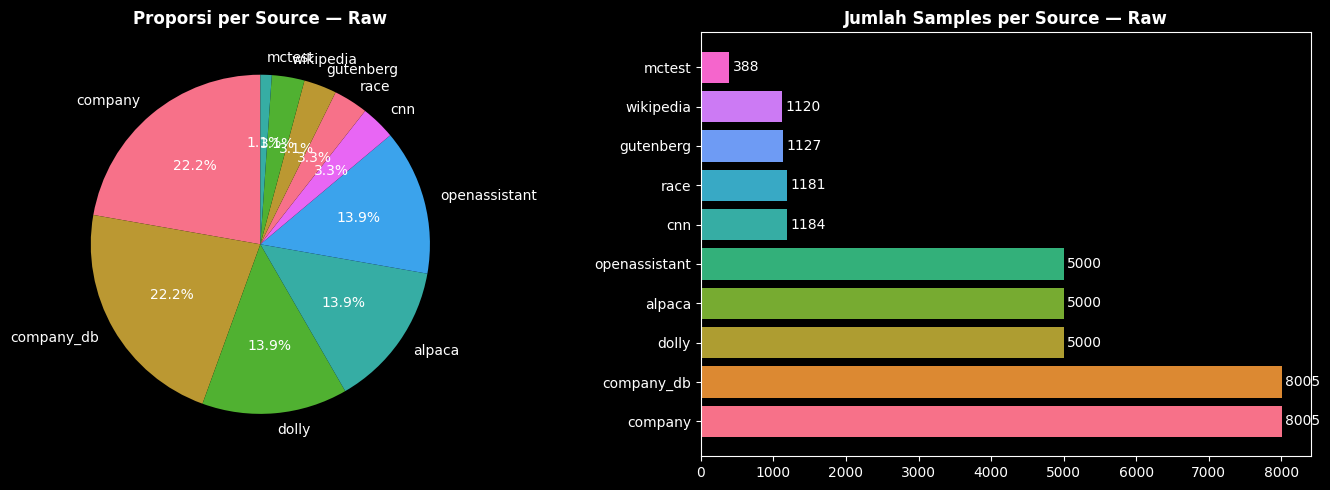

In [6]:
if not df_raw.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    vc = df_raw['source'].value_counts()
    axes[0].pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Proporsi per Source — Raw', fontweight='bold')
    axes[1].barh(vc.index, vc.values, color=sns.color_palette('husl', len(vc)))
    axes[1].set_title('Jumlah Samples per Source — Raw', fontweight='bold')
    for i,v in enumerate(vc.values):
        axes[1].text(v+50, i, str(v), va='center')
    plt.tight_layout()
    plt.show()

## 1.5 Boxplot per Source — Raw

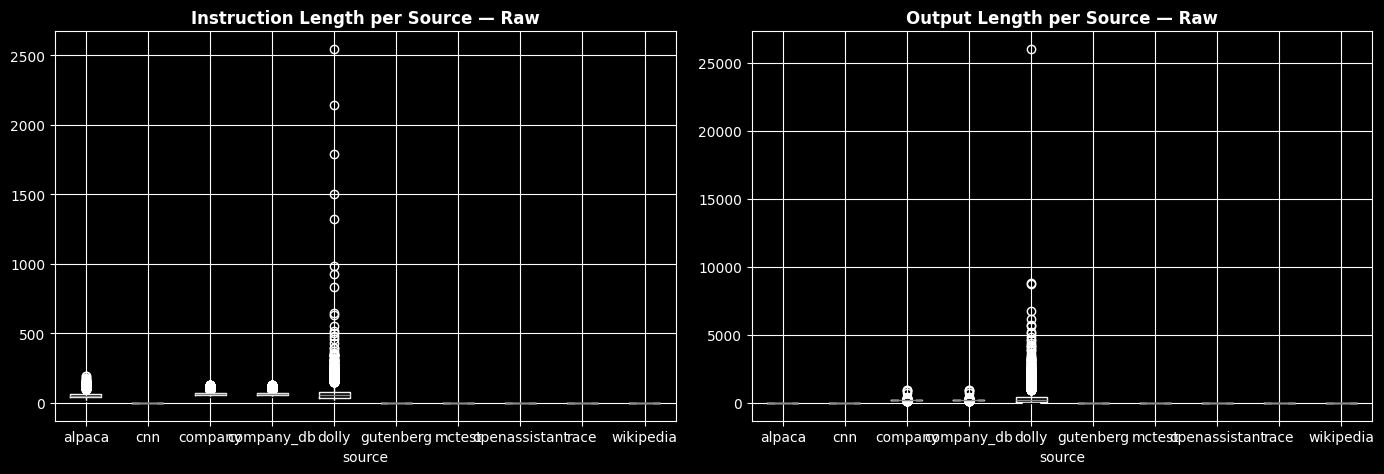

In [7]:
if not df_raw.empty and 'output_length' in df_raw.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if 'instruction_length' in df_raw.columns:
        df_raw.boxplot(column='instruction_length', by='source', ax=axes[0])
        axes[0].set_title('Instruction Length per Source — Raw', fontweight='bold')
    df_raw.boxplot(column='output_length', by='source', ax=axes[1])
    axes[1].set_title('Output Length per Source — Raw', fontweight='bold')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

## 1.6 Scatter Plot — Raw

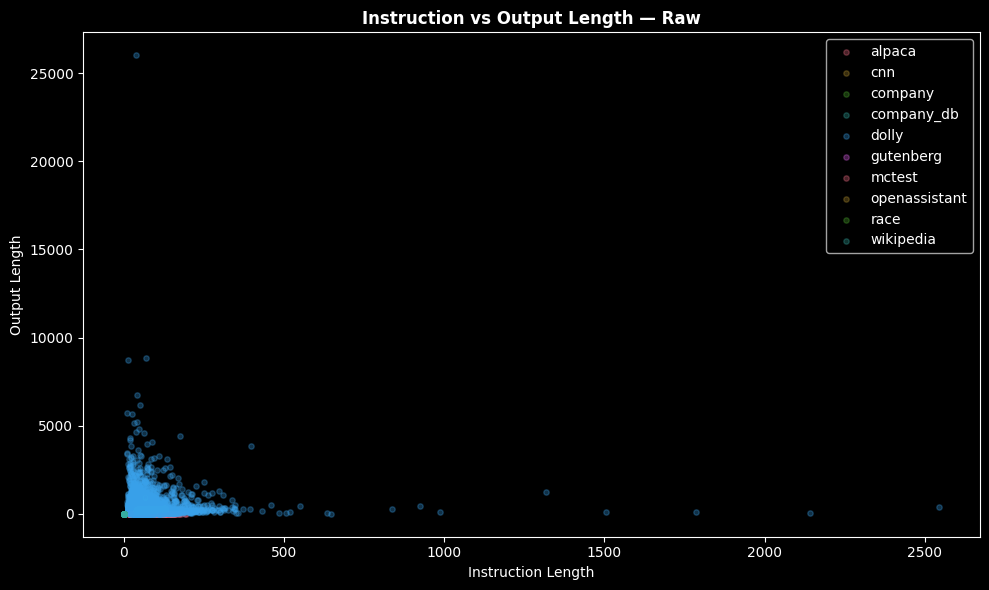

In [8]:
if not df_raw.empty and 'instruction_length' in df_raw.columns and 'output_length' in df_raw.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    for src, grp in df_raw.groupby('source'):
        ax.scatter(grp['instruction_length'], grp['output_length'],
                   alpha=0.3, s=15, label=src)
    ax.set_xlabel('Instruction Length')
    ax.set_ylabel('Output Length')
    ax.set_title('Instruction vs Output Length — Raw', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 1.7 Correlation Heatmap — Raw

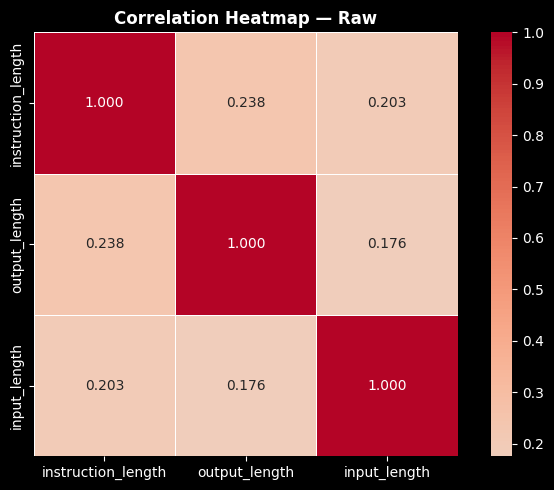

In [9]:
if not df_raw.empty and len(len_cols) >= 2:
    fig, ax = plt.subplots(figsize=(7, 5))
    corr = df_raw[len_cols].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
                ax=ax, linewidths=0.5, square=True)
    ax.set_title('Correlation Heatmap — Raw', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 1.8 Statistik per Source — Raw

In [10]:
if not df_raw.empty:
    for src in df_raw['source'].unique():
        grp = df_raw[df_raw['source']==src]
        avail = [c for c in len_cols if c in grp.columns]
        print(f'\n--- {src} ({len(grp)} samples) ---')
        if avail:
            print(grp[avail].describe())


--- dolly (5000 samples) ---
       instruction_length  output_length  input_length
count         5000.000000    5000.000000   5000.000000
mean            69.392200     361.838600    354.616400
std             79.613275     642.477516   1007.443543
min             10.000000       1.000000      0.000000
25%             36.000000      79.000000      0.000000
50%             54.000000     186.000000      0.000000
75%             81.000000     438.250000    421.250000
max           2545.000000   26018.000000  23505.000000

--- alpaca (5000 samples) ---
       instruction_length  output_length  input_length
count         5000.000000         5000.0        5000.0
mean            55.986600            0.0           0.0
std             18.889896            0.0           0.0
min             15.000000            0.0           0.0
25%             44.000000            0.0           0.0
50%             53.000000            0.0           0.0
75%             65.000000            0.0           0.0
max 

---
# SESI 2 — EDA Dataset Preprocessed
Membaca dataset yang **sudah diproses** dari `data/formatted/` (train & val).

## 2.1 Load Preprocessed Data

In [11]:
try:
    train_ds = load_from_disk(os.path.join(config.FORMATTED_DATA_DIR, 'train'))
    val_ds = load_from_disk(os.path.join(config.FORMATTED_DATA_DIR, 'val'))
    df_train = train_ds.to_pandas()
    df_val = val_ds.to_pandas()
    df_proc = pd.concat([df_train, df_val], ignore_index=True)
    df_proc['split'] = ['train']*len(df_train) + ['val']*len(df_val)
    print(f'Train: {len(df_train)} | Val: {len(df_val)} | Total: {len(df_proc)}')
    print(f'Columns: {list(df_proc.columns)}')
except Exception as e:
    df_proc = pd.DataFrame()
    print(f'Formatted data belum tersedia: {e}')

Train: 41866 | Val: 4652 | Total: 46518
Columns: ['instruction', 'input', 'output', 'text', 'source', 'split']


## 2.2 Informasi Dasar — Preprocessed

In [12]:
if not df_proc.empty:
    print(f'Shape: {df_proc.shape}')
    print(f'\nSource distribution:')
    print(df_proc['source'].value_counts())
    print(f'\nSplit distribution:')
    print(df_proc['split'].value_counts())
    df_proc.head(5)

Shape: (46518, 6)

Source distribution:
source
openassistant    9947
coqa             9758
alpaca           9423
dolly            9399
company          7991
Name: count, dtype: int64

Split distribution:
split
train    41866
val       4652
Name: count, dtype: int64


## 2.3 Distribusi Panjang Teks — Preprocessed

In [13]:
if not df_proc.empty:
    for c in ['instruction','output','input']:
        if c in df_proc.columns:
            df_proc[c] = df_proc[c].fillna('').astype(str)
            df_proc[f'{c}_length'] = df_proc[c].str.len()
    if 'text' in df_proc.columns:
        df_proc['text_length'] = df_proc['text'].fillna('').astype(str).str.len()

    pcols = [c for c in ['instruction_length','output_length','input_length','text_length']
             if c in df_proc.columns]
    print(df_proc[pcols].describe())

       instruction_length  output_length  input_length   text_length
count        46518.000000   46518.000000  46518.000000  46518.000000
mean            66.618148     317.485769    220.450600    669.011372
std             97.967734     454.051333    454.412046    600.475911
min              5.000000       1.000000      0.000000     65.000000
25%             35.000000      37.000000      0.000000    383.000000
50%             53.000000     205.000000     23.500000    602.000000
75%             71.000000     375.000000    490.000000    664.000000
max           4667.000000    9964.000000  23491.000000  24019.000000


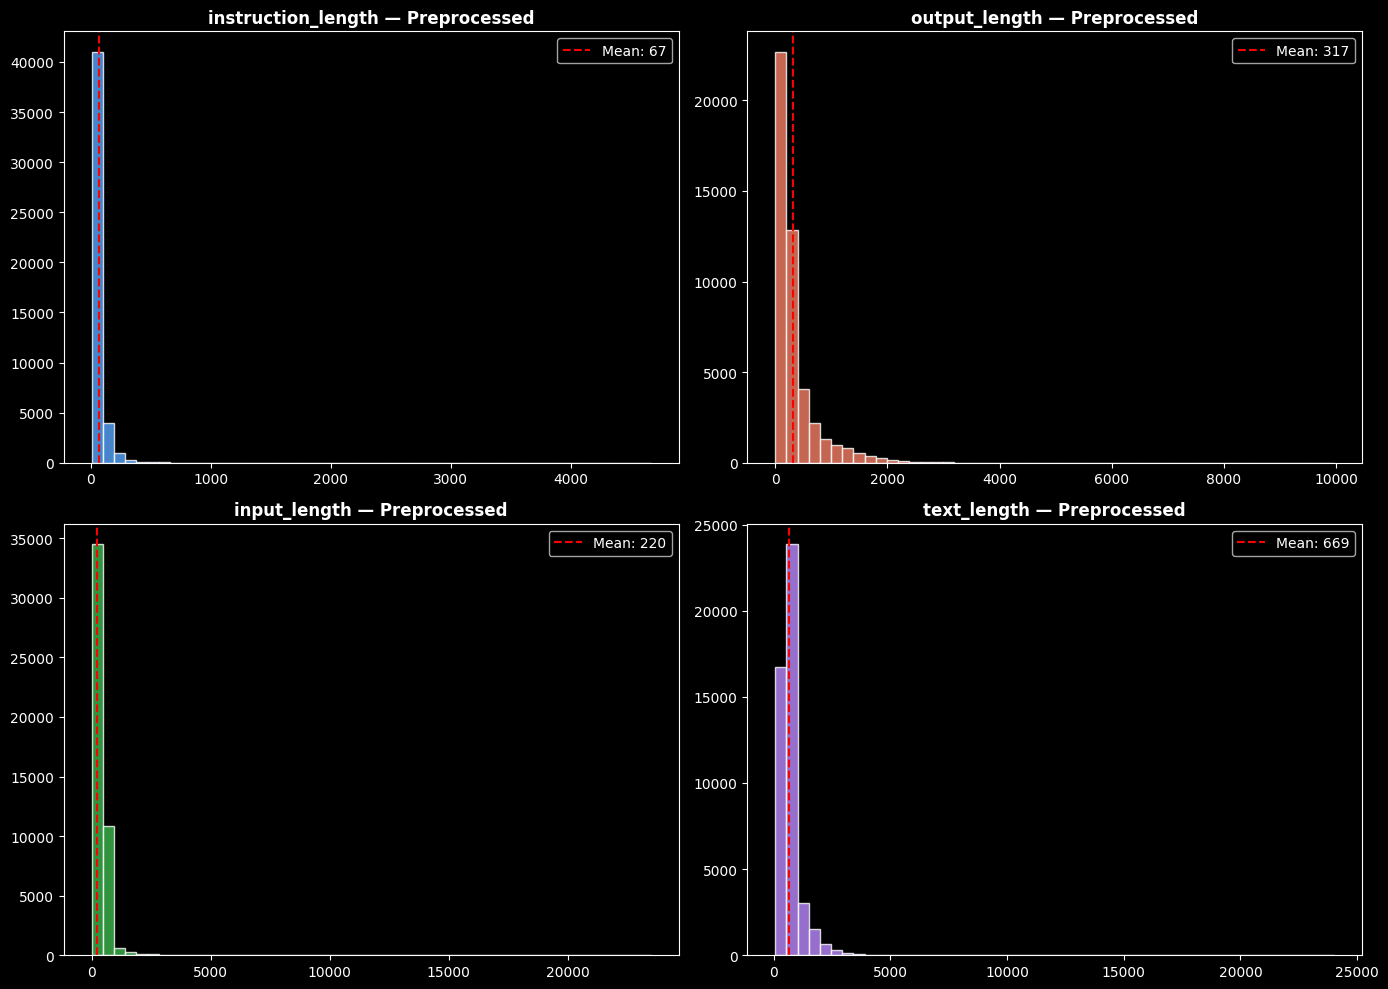

In [14]:
if not df_proc.empty and pcols:
    n = len(pcols)
    rows_n = (n+1)//2
    fig, axes = plt.subplots(rows_n, 2, figsize=(14, 5*rows_n))
    axes = axes.flatten()
    colors = ['#58a6ff','#f78166','#3fb950','#bc8cff']
    for i, col in enumerate(pcols):
        axes[i].hist(df_proc[col], bins=50, color=colors[i%4], edgecolor='white', alpha=0.8)
        axes[i].set_title(f'{col} — Preprocessed', fontweight='bold')
        axes[i].axvline(df_proc[col].mean(), color='red', ls='--',
                        label=f'Mean: {df_proc[col].mean():.0f}')
        axes[i].legend()
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

## 2.4 Distribusi Sumber — Preprocessed

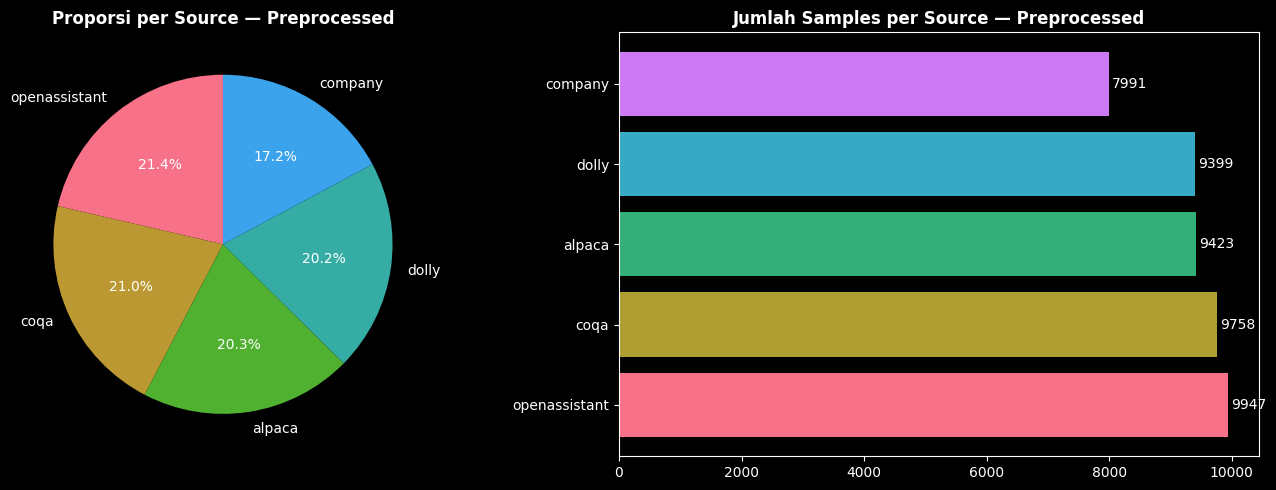

In [15]:
if not df_proc.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    vc = df_proc['source'].value_counts()
    axes[0].pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Proporsi per Source — Preprocessed', fontweight='bold')
    axes[1].barh(vc.index, vc.values, color=sns.color_palette('husl', len(vc)))
    axes[1].set_title('Jumlah Samples per Source — Preprocessed', fontweight='bold')
    for i,v in enumerate(vc.values):
        axes[1].text(v+50, i, str(v), va='center')
    plt.tight_layout()
    plt.show()

## 2.5 Boxplot per Source — Preprocessed

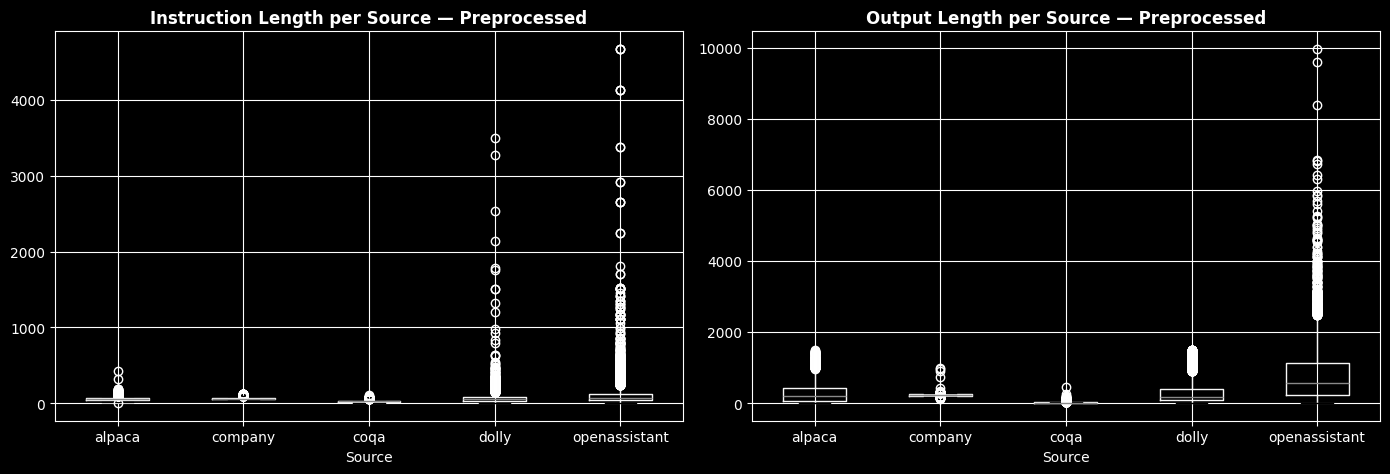

In [16]:
if not df_proc.empty and 'output_length' in df_proc.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df_proc.boxplot(column='instruction_length', by='source', ax=axes[0])
    axes[0].set_title('Instruction Length per Source — Preprocessed', fontweight='bold')
    axes[0].set_xlabel('Source')
    df_proc.boxplot(column='output_length', by='source', ax=axes[1])
    axes[1].set_title('Output Length per Source — Preprocessed', fontweight='bold')
    axes[1].set_xlabel('Source')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

## 2.6 Scatter Plot — Preprocessed

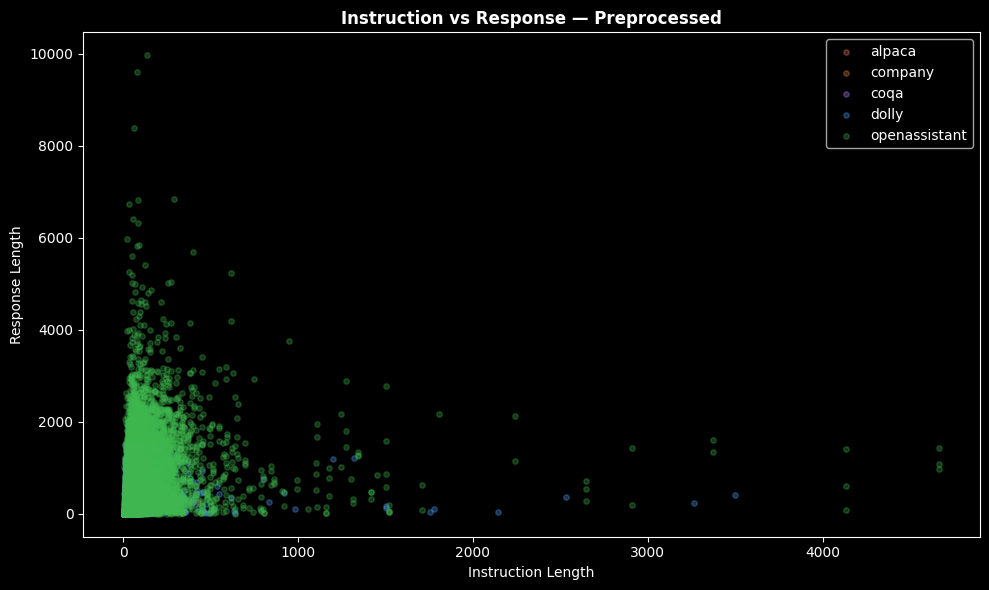

In [17]:
if not df_proc.empty and 'instruction_length' in df_proc.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    cmap = {'dolly':'#58a6ff','alpaca':'#f78166','openassistant':'#3fb950',
            'coqa':'#bc8cff','company':'#f0883e'}
    for src, grp in df_proc.groupby('source'):
        ax.scatter(grp['instruction_length'], grp['output_length'],
                   alpha=0.3, s=15, label=src, color=cmap.get(src,'gray'))
    ax.set_xlabel('Instruction Length')
    ax.set_ylabel('Response Length')
    ax.set_title('Instruction vs Response — Preprocessed', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 2.7 Correlation Heatmap — Preprocessed

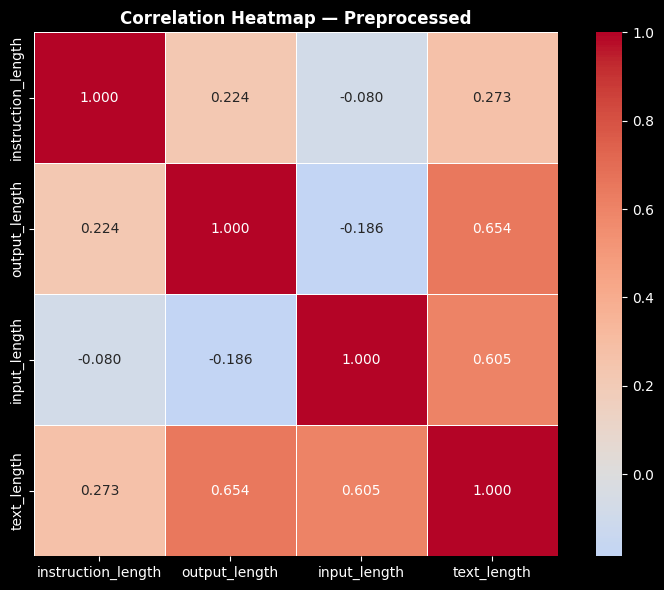

In [18]:
if not df_proc.empty and len(pcols) >= 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    corr = df_proc[pcols].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
                ax=ax, linewidths=0.5, square=True)
    ax.set_title('Correlation Heatmap — Preprocessed', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 2.8 Token Frequency (Top Words) — Preprocessed

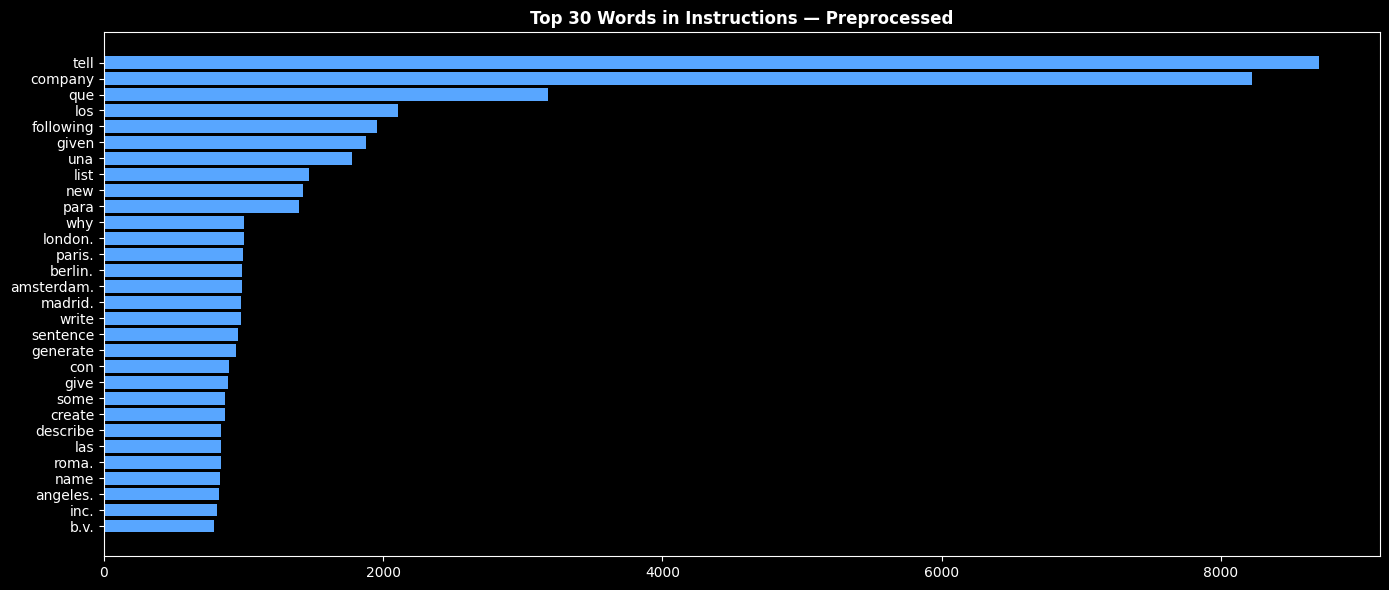

In [19]:
if not df_proc.empty and 'instruction' in df_proc.columns:
    all_words = ' '.join(df_proc['instruction'].fillna('')).lower().split()
    stop = {'the','a','an','is','are','was','were','be','been','being',
            'have','has','had','do','does','did','will','would','could',
            'should','may','might','shall','can','to','of','in','for',
            'on','with','at','by','from','as','into','about','and','or',
            'but','not','no','this','that','it','i','you','he','she','we',
            'they','me','him','her','us','them','my','your','his','its',
            'our','their','what','which','who','whom','when','where','how',
            'if','than','so','up','out','all','just','also'}
    filtered = [w for w in all_words if w not in stop and len(w) > 2]
    top30 = Counter(filtered).most_common(30)

    fig, ax = plt.subplots(figsize=(14, 6))
    words, counts = zip(*top30)
    ax.barh(range(len(words)), counts, color='#58a6ff')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_title('Top 30 Words in Instructions — Preprocessed', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 2.9 Statistik per Source — Preprocessed

In [20]:
if not df_proc.empty:
    for src in sorted(df_proc['source'].unique()):
        grp = df_proc[df_proc['source']==src]
        avail = [c for c in pcols if c in grp.columns]
        print(f'\n--- {src} ({len(grp)} samples) ---')
        if avail:
            print(grp[avail].describe())


--- alpaca (9423 samples) ---
       instruction_length  output_length  input_length  text_length
count         9423.000000    9423.000000   9423.000000  9423.000000
mean            57.066115     268.001486     25.426191   396.493792
std             19.596871     252.849218     61.848435   258.316871
min              9.000000      10.000000      0.000000    65.000000
25%             44.000000      57.000000      0.000000   187.000000
50%             54.000000     189.000000      0.000000   324.000000
75%             66.000000     421.000000     29.000000   547.000000
max            431.000000    1495.000000   1514.000000  2712.000000

--- company (7991 samples) ---
       instruction_length  output_length  input_length  text_length
count         7991.000000    7991.000000   7991.000000  7991.000000
mean            63.318859     227.253535    237.868978   605.441372
std             12.780899      26.264126     23.864983    55.702790
min             39.000000     118.000000    148.00000

---
## Ringkasan

| Sesi | Data | Sumber |
|------|------|--------|
| Sesi 1 | Dataset RAW | `data/raw/` + Supabase `company_data` |
| Sesi 2 | Dataset Preprocessed | `data/formatted/train` & `val` |

| Visualisasi | Keterangan |
|-------------|------------|
| Histogram | Distribusi panjang instruction, output, input, text |
| Pie Chart | Proporsi dataset per sumber |
| Bar Chart | Jumlah samples per sumber |
| Boxplot | Perbandingan panjang teks antar sumber |
| Scatter Plot | Hubungan instruction vs output length |
| Heatmap | Korelasi antar fitur numerik |
| Token Freq | Top 30 kata paling sering muncul |